<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html notebook.do.txt  -->
<!-- dom:TITLE: Lipkin model and PMMs -->

# Lipkin model and PMMs
**Morten Hjorth-Jensen**, Department of Physics, University of Oslo, Norway and the PMM gang

Date: **November 2025**

## Plan for these notes
1. Add notes about the Lipkin model

2. Add notes about the Lipkin model and its coupling to the environment (dissipation and dephasing)

3. Include notes about the time evolution

4. Add notes about entanglement measures

## Code example where we use the Lipkin model and PMMs

Lipkin (symmetric J=N/2, N=20), dim = 21


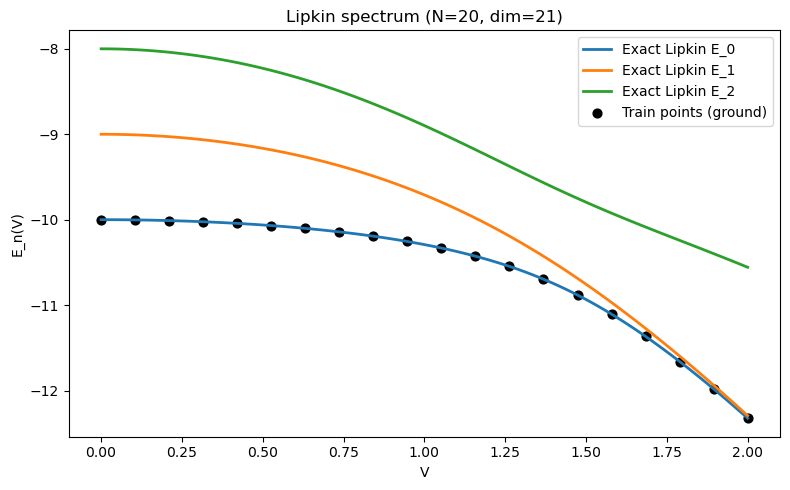

[Lipkin big PMM] iter     0  loss = 8.399799e+01
[Lipkin big PMM] iter   200  loss = 5.106408e-01
[Lipkin big PMM] iter   400  loss = 4.760259e-02
[Lipkin big PMM] iter   600  loss = 3.233570e-02
[Lipkin big PMM] iter   800  loss = 1.793193e-02
[Lipkin big PMM] iter  1000  loss = 7.411620e-03
[Lipkin big PMM] iter  1200  loss = 3.262237e-03
[Lipkin big PMM] iter  1400  loss = 2.079273e-03
[Lipkin big PMM] iter  1600  loss = 1.560387e-03
[Lipkin big PMM] iter  1800  loss = 1.234819e-03
[Lipkin big PMM] iter  1999  loss = 1.023605e-03


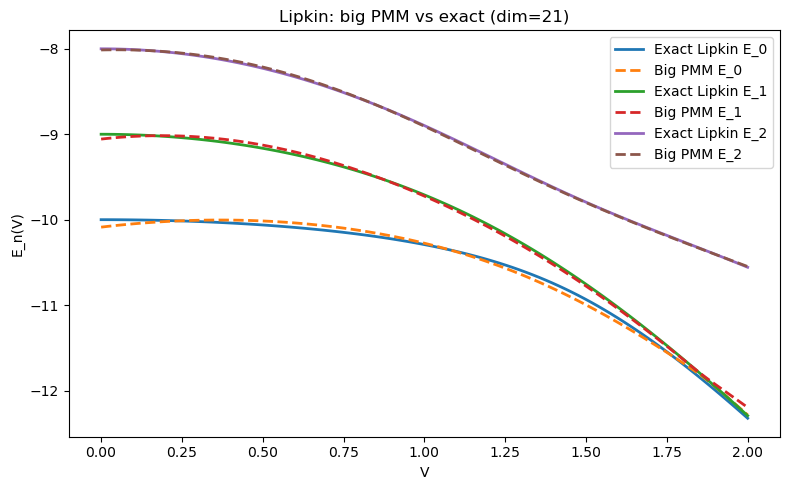


Lipkin: reduced PMM with n_eff = 10
[Lipkin reduced PMM] iter     0  loss = 9.135415e+01
[Lipkin reduced PMM] iter   200  loss = 6.679131e+00
[Lipkin reduced PMM] iter   400  loss = 2.851207e+00
[Lipkin reduced PMM] iter   600  loss = 1.586532e+00
[Lipkin reduced PMM] iter   800  loss = 7.782747e-01
[Lipkin reduced PMM] iter  1000  loss = 3.495826e-01
[Lipkin reduced PMM] iter  1200  loss = 1.586424e-01
[Lipkin reduced PMM] iter  1400  loss = 8.596244e-02
[Lipkin reduced PMM] iter  1600  loss = 6.311355e-02
[Lipkin reduced PMM] iter  1800  loss = 5.711688e-02
[Lipkin reduced PMM] iter  1999  loss = 5.527728e-02


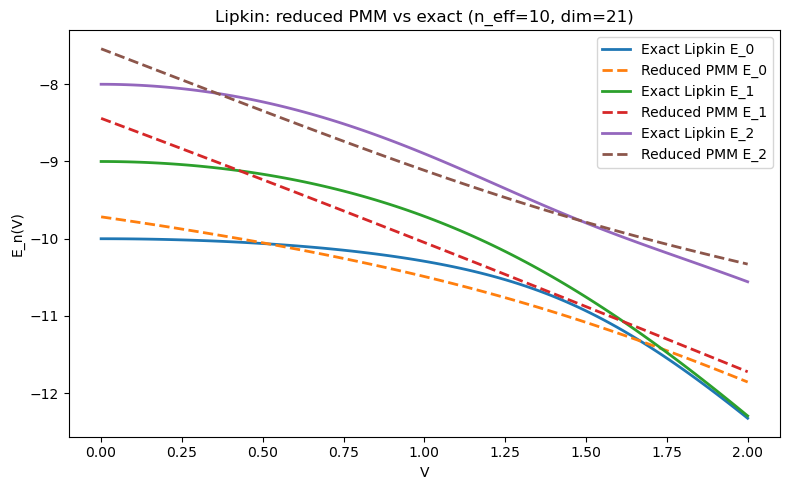

In [1]:
%matplotlib inline

import math
import numpy as np
from itertools import combinations
from matplotlib import pyplot as plt

# ============================================================
# Base class for many-body models (for structure)
# ============================================================

class ManyBodyModel:
    """
    Abstract base for a parametric Hamiltonian H(g),
    where g is a scalar control parameter (V, G, ...).
    """

    def __init__(self, dim, name="Model"):
        self.dim = dim
        self.name = name

    def hamiltonian(self, g):
        """
        Return the Hamiltonian H(g) as a dim x dim numpy array.
        Must be implemented by subclasses.
        """
        raise NotImplementedError

    def spectrum(self, grid, k):
        """
        Compute lowest k eigenvalues for each value in grid.

        Parameters
        ----------
        grid : array-like
            1D array of control parameters g.
        k : int
            Number of lowest eigenvalues to return.

        Returns
        -------
        E : ndarray, shape (len(grid), k)
        """
        from numpy.linalg import eigvalsh
        E = []
        for g in grid:
            H = self.hamiltonian(g)
            evals = eigvalsh(H)
            E.append(evals[:k])
        return np.array(E)


# ============================================================
# Lipkin model
# ============================================================

class LipkinModel(ManyBodyModel):
    """
    Lipkin-Meshkov-Glick model:

        H = epsilon * Jz + (V/N) * (Jx^2 - Jy^2)

    where (Jx, Jy, Jz) are collective spin operators.

    Can work in:
      - full 2^N Hilbert space
      - or symmetric J = N/2 sector (dim = N+1)
    """

    def __init__(self, N, epsilon=1.0, use_symmetric_sector=True):
        self.N = N
        self.epsilon = epsilon
        self.use_symmetric_sector = use_symmetric_sector

        if use_symmetric_sector:
            Jx, Jy, Jz = self._build_collective_operators_symmetric(N)
            dim = Jx.shape[0]  # N+1
            name = f"Lipkin (symmetric J=N/2, N={N})"
        else:
            Jx, Jy, Jz = self._build_collective_operators_full(N)
            dim = Jx.shape[0]  # 2^N
            name = f"Lipkin (full space, N={N})"

        super().__init__(dim=dim, name=name)

        self.Jx = Jx
        self.Jy = Jy
        self.Jz = Jz

        # Precompute H0 and Hint: H(V) = H0 + V*Hint
        self.H0 = epsilon * self.Jz
        self.Hint = (1.0 / N) * (self.Jx @ self.Jx - self.Jy @ self.Jy)

    # -- public API --

    def hamiltonian(self, V):
        """
        Lipkin Hamiltonian for interaction strength V.
        """
        return self.H0 + V * self.Hint

    # -- internal helpers --

    @staticmethod
    def _build_collective_operators_full(N):
        """
        Build Jx, Jy, Jz in the full 2^N Hilbert space
        from tensor products of single-qubit Pauli matrices.
        """
        dim = 2**N
        sx = np.array([[0, 1],
                       [1, 0]], dtype=np.complex128)
        sy = np.array([[0, -1j],
                       [1j, 0]], dtype=np.complex128)
        sz = np.array([[1, 0],
                       [0, -1]], dtype=np.complex128)
        id2 = np.eye(2, dtype=np.complex128)

        Jx = np.zeros((dim, dim), dtype=np.complex128)
        Jy = np.zeros((dim, dim), dtype=np.complex128)
        Jz = np.zeros((dim, dim), dtype=np.complex128)

        for site in range(N):
            ops = []
            for pos in range(N):
                if pos == site:
                    ops.append((sx, sy, sz))
                else:
                    ops.append((id2, id2, id2))

            sx_i = ops[0][0]
            sy_i = ops[0][1]
            sz_i = ops[0][2]
            for pos in range(1, N):
                sx_i = np.kron(sx_i, ops[pos][0])
                sy_i = np.kron(sy_i, ops[pos][1])
                sz_i = np.kron(sz_i, ops[pos][2])

            Jx += 0.5 * sx_i
            Jy += 0.5 * sy_i
            Jz += 0.5 * sz_i

        return Jx, Jy, Jz

    @staticmethod
    def _build_collective_operators_symmetric(N):
        """
        Build Jx, Jy, Jz in the fully symmetric total-spin sector J = N/2.

        Basis: |J, M>, M = J, J-1, ..., -J. Dimension = N+1.
        """
        J = N / 2.0
        dim = int(2 * J + 1)

        M_vals = np.arange(J, -J - 1, -1, dtype=float)

        Jp = np.zeros((dim, dim), dtype=np.complex128)
        Jm = np.zeros((dim, dim), dtype=np.complex128)
        Jz = np.zeros((dim, dim), dtype=np.complex128)

        for i, M in enumerate(M_vals):
            # J_z |J,M> = M |J,M>
            Jz[i, i] = M

            # J_+ |J,M> -> |J,M+1>, index i-1
            if i > 0:
                coef = math.sqrt(J * (J + 1.0) - M * (M + 1.0))
                Jp[i - 1, i] = coef

            # J_- |J,M> -> |J,M-1>, index i+1
            if i < dim - 1:
                coef = math.sqrt(J * (J + 1.0) - M * (M - 1.0))
                Jm[i + 1, i] = coef

        Jx = 0.5 * (Jp + Jm)
        Jy = -0.5j * (Jp - Jm)

        return Jx, Jy, Jz



# ============================================================
# Parametric Matrix Model M(c) = A + c B
# ============================================================

class ParametricMatrixModel:
    """
    Parametric Matrix Model (PMM):

        M(c) = A + c B

    where A and B are real symmetric n x n matrices.
    This class can be trained to reproduce a set of target
    eigenvalues E_true(c) (e.g., from a many-body model)
    as a function of the control parameter c.

    Training uses analytic gradients of eigenvalues:
      d λ_l / dH = v_l v_l^T
    """

    def __init__(self, dim, k_levels,
                 lr=1e-2, n_iter=2000,
                 init_scale=0.1, seed=0,
                 label="PMM"):
        """
        Parameters
        ----------
        dim : int
            Matrix dimension of the PMM.
        k_levels : int
            Number of lowest eigenvalues to fit.
        lr : float
            Learning rate for Adam.
        n_iter : int
            Number of training iterations.
        init_scale : float
            Scale of random initialization.
        seed : int
            RNG seed.
        label : str
            Label for logging.
        """
        self.dim = dim
        self.k_levels = k_levels
        self.lr = lr
        self.n_iter = n_iter
        self.init_scale = init_scale
        self.seed = seed
        self.label = label

        self.A, self.B = self._init_params(dim, seed, init_scale)

    # -- initialization --

    @staticmethod
    def _init_params(n, seed=0, scale=0.1):
        rng = np.random.default_rng(seed)
        A = scale * rng.normal(size=(n, n))
        B = scale * rng.normal(size=(n, n))
        A = 0.5 * (A + A.T)
        B = 0.5 * (B + B.T)
        return A, B

    # -- PMM Hamiltonian and spectrum --

    def hamiltonian(self, c):
        """
        Return M(c) = A + c B (real symmetric).
        """
        H = self.A + c * self.B
        return 0.5 * (H + H.T)

    def eigensystem(self, c):
        """
        Lowest k eigenvalues and corresponding eigenvectors of M(c).
        """
        from numpy.linalg import eigh
        H = self.hamiltonian(c)
        evals, evecs = eigh(H)
        return evals[:self.k_levels], evecs[:, :self.k_levels]

    def spectrum(self, c_grid):
        """
        Lowest k eigenvalues for an array of control parameters.

        Returns
        -------
        E_pred : ndarray, shape (len(c_grid), k_levels)
        """
        vals = []
        for c in c_grid:
            e, _ = self.eigensystem(c)
            vals.append(e)
        return np.array(vals)

    # -- training (spectrum loss only) --

    @staticmethod
    def _adam_update(param, grad_param, m, v, t, lr=1e-2,
                     beta1=0.9, beta2=0.999, eps=1e-8):
        m = beta1 * m + (1 - beta1) * grad_param
        v = beta2 * v + (1 - beta2) * (grad_param * grad_param)
        m_hat = m / (1 - beta1 ** (t + 1))
        v_hat = v / (1 - beta2 ** (t + 1))
        param = param - lr * m_hat / (np.sqrt(v_hat) + eps)
        return param, m, v

    def fit(self, params_train, E_train):
        """
        Fit the PMM so that the lowest k eigenvalues of M(c)
        approximate E_train(c) for c in params_train.

        Parameters
        ----------
        params_train : array-like, shape (n_points,)
            Control parameter values c.
        E_train : ndarray, shape (n_points, k_levels)
            Target eigenvalues (e.g., from Lipkin or Pairing).
        """
        A = self.A.copy()
        B = self.B.copy()
        n = self.dim
        n_points, k = E_train.shape
        assert k == self.k_levels

        mA = np.zeros_like(A)
        vA = np.zeros_like(A)
        mB = np.zeros_like(B)
        vB = np.zeros_like(B)

        for t in range(self.n_iter):
            grad_A = np.zeros_like(A)
            grad_B = np.zeros_like(B)
            loss_val = 0.0

            for idx, p in enumerate(params_train):
                # PMM eigensystem at param p
                evals, evecs = self._eigs_for_grad(A, B, p)
                diff = evals[:k] - E_train[idx]  # (k,)

                loss_val += np.sum(diff**2)

                # Gradient of eigenvalue λ_l wrt H is v_l v_l^T
                factor = 2.0 / (n_points * k)
                for l in range(k):
                    g_coeff = factor * diff[l]
                    v = evecs[:, l]
                    outer = np.outer(v, v)
                    grad_A += g_coeff * outer
                    grad_B += g_coeff * p * outer

            loss_val /= (n_points * k)

            # Adam update
            A, mA, vA = self._adam_update(A, grad_A, mA, vA, t, lr=self.lr)
            B, mB, vB = self._adam_update(B, grad_B, mB, vB, t, lr=self.lr)

            # Re-symmetrize
            A = 0.5 * (A + A.T)
            B = 0.5 * (B + B.T)

            if t % 200 == 0 or t == self.n_iter - 1:
                print(f"[{self.label}] iter {t:5d}  loss = {loss_val:.6e}")

        self.A, self.B = A, B

    @staticmethod
    def _eigs_for_grad(A, B, c):
        """
        Helper: eigenvalues + eigenvectors of H(c) for gradient calculations.
        """
        from numpy.linalg import eigh
        H = 0.5 * ((A + c * B) + (A + c * B).T)
        evals, evecs = eigh(H)
        return evals, evecs


# ============================================================
# Demo / usage
# ============================================================

if __name__ == "__main__":
    # ------------------------
    # LIPKIN EXAMPLE
    # ------------------------
    N = 20
    epsilon_lip = 1.0
    k_levels = 3

    use_symmetric = True  # True: J=N/2 block; False: full 2^N
    lipkin = LipkinModel(N=N, epsilon=epsilon_lip,
                         use_symmetric_sector=use_symmetric)
    print(f"{lipkin.name}, dim = {lipkin.dim}")

    V_train = np.linspace(0.0, 2.0, 20)
    V_test = np.linspace(0.0, 2.0, 100)

    E_train_lip = lipkin.spectrum(V_train, k=k_levels)
    E_test_lip = lipkin.spectrum(V_test, k=k_levels)

    # Plot exact Lipkin spectrum
    plt.figure(figsize=(8, 5))
    for ell in range(k_levels):
        plt.plot(V_test, E_test_lip[:, ell], lw=2,
                 label=f"Exact Lipkin E_{ell}")
    plt.scatter(V_train, E_train_lip[:, 0], color="k", s=40,
                label="Train points (ground)")
    plt.xlabel("V")
    plt.ylabel("E_n(V)")
    plt.title(f"Lipkin spectrum (N={N}, dim={lipkin.dim})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Big PMM (same dim as Lipkin representation)
    pmm_big_lip = ParametricMatrixModel(dim=lipkin.dim,
                                        k_levels=k_levels,
                                        lr=1e-2,
                                        n_iter=2000,
                                        init_scale=0.1,
                                        seed=123,
                                        label="Lipkin big PMM")
    pmm_big_lip.fit(V_train, E_train_lip)
    E_pred_big_lip = pmm_big_lip.spectrum(V_test)

    plt.figure(figsize=(8, 5))
    for ell in range(k_levels):
        plt.plot(V_test, E_test_lip[:, ell], lw=2,
                 label=f"Exact Lipkin E_{ell}")
        plt.plot(V_test, E_pred_big_lip[:, ell], "--", lw=2,
                 label=f"Big PMM E_{ell}")
    plt.xlabel("V")
    plt.ylabel("E_n(V)")
    plt.title(f"Lipkin: big PMM vs exact (dim={lipkin.dim})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Reduced PMM (n_eff < dim)
    n_eff_lip = min(10, lipkin.dim)
    print(f"\nLipkin: reduced PMM with n_eff = {n_eff_lip}")
    pmm_red_lip = ParametricMatrixModel(dim=n_eff_lip,
                                        k_levels=k_levels,
                                        lr=5e-3,
                                        n_iter=2000,
                                        init_scale=0.1,
                                        seed=456,
                                        label="Lipkin reduced PMM")
    pmm_red_lip.fit(V_train, E_train_lip)
    E_pred_red_lip = pmm_red_lip.spectrum(V_test)

    plt.figure(figsize=(8, 5))
    for ell in range(k_levels):
        plt.plot(V_test, E_test_lip[:, ell], lw=2,
                 label=f"Exact Lipkin E_{ell}")
        plt.plot(V_test, E_pred_red_lip[:, ell], "--", lw=2,
                 label=f"Reduced PMM E_{ell}")
    plt.xlabel("V")
    plt.ylabel("E_n(V)")
    plt.title(f"Lipkin: reduced PMM vs exact (n_eff={n_eff_lip}, dim={lipkin.dim})")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Lipkin model and time evolution

Lipkin (symmetric J=N/2, N=4), dim = 5


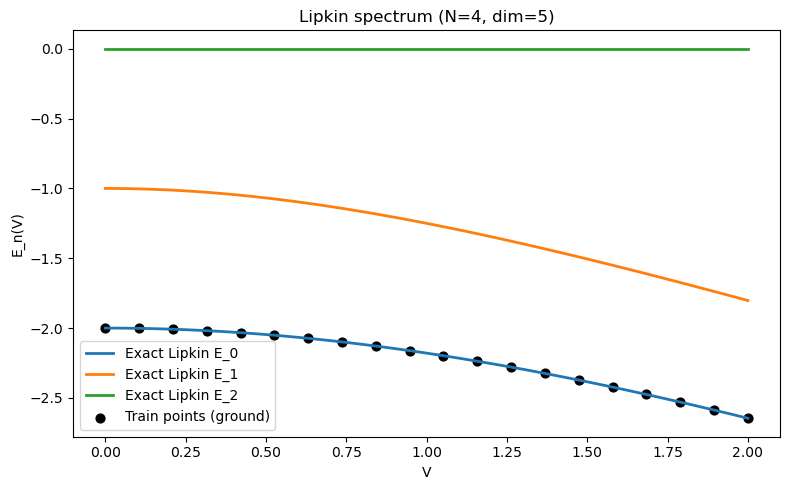

[Lipkin big PMM / spectrum] epoch    0, loss = 1.959766e+00
[Lipkin big PMM / spectrum] epoch  200, loss = 1.553603e-03
[Lipkin big PMM / spectrum] epoch  400, loss = 9.713227e-04
[Lipkin big PMM / spectrum] epoch  600, loss = 7.360373e-04
[Lipkin big PMM / spectrum] epoch  799, loss = 4.101200e-04


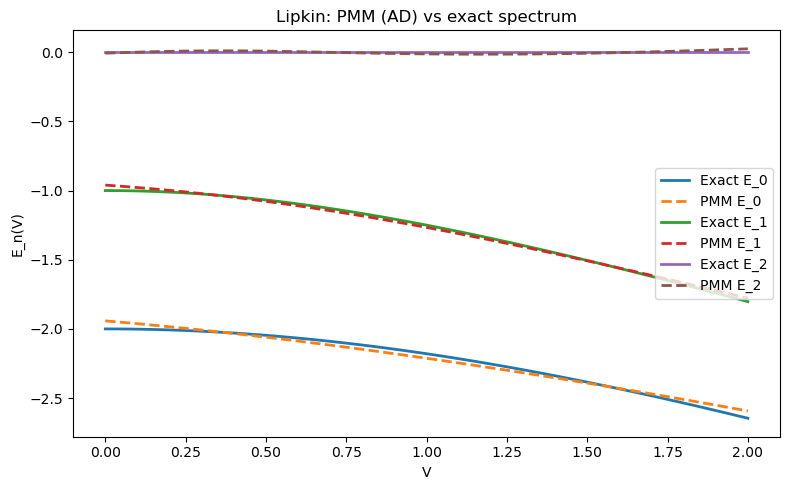

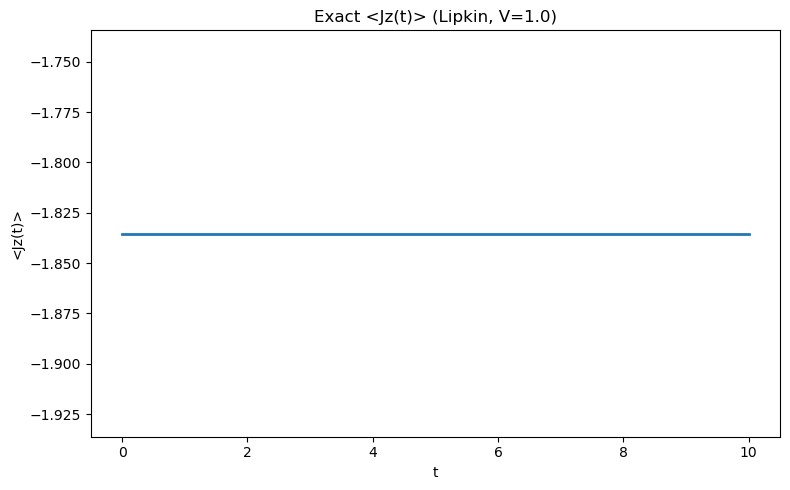


Time training PMM on <Jz(t)> using AD ...
[Lipkin big PMM / time] epoch    0, loss = 2.772047e+00
[Lipkin big PMM / time] epoch   10, loss = 1.765196e+00
[Lipkin big PMM / time] epoch   20, loss = 1.358713e+00
[Lipkin big PMM / time] epoch   30, loss = 1.219388e+00
[Lipkin big PMM / time] epoch   40, loss = 1.087741e+00
[Lipkin big PMM / time] epoch   50, loss = 9.588659e-01
[Lipkin big PMM / time] epoch   60, loss = 8.531554e-01
[Lipkin big PMM / time] epoch   70, loss = 7.641779e-01
[Lipkin big PMM / time] epoch   79, loss = 6.938191e-01


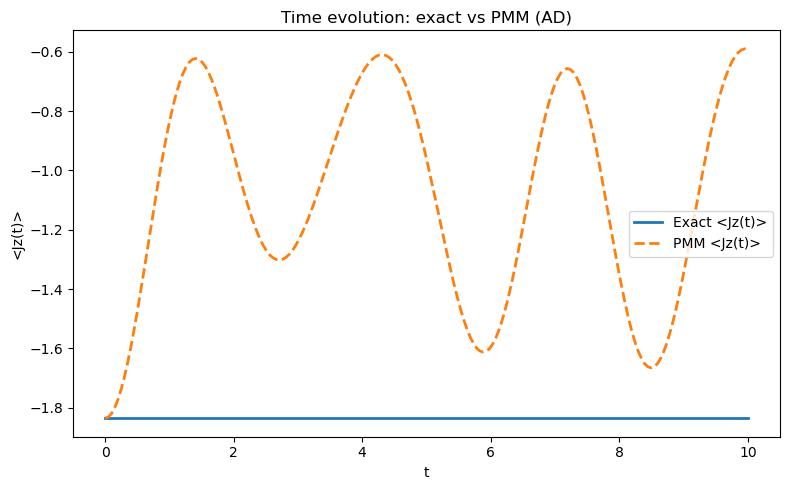

In [2]:
import math
import numpy as np
from itertools import combinations
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# Base class for many-body models (NumPy)
# ============================================================

class ManyBodyModel:
    """
    Abstract base for a parametric Hamiltonian H(g),
    where g is a scalar control parameter (V, G, ...).
    """

    def __init__(self, dim, name="Model"):
        self.dim = dim
        self.name = name

    # ------------- core API -------------

    def hamiltonian(self, g):
        """
        Return the Hamiltonian H(g) as a dim x dim numpy array.
        Must be implemented by subclasses.
        """
        raise NotImplementedError

    def spectrum(self, grid, k):
        """
        Compute lowest k eigenvalues for each value in grid.

        Returns: E (len(grid), k)
        """
        from numpy.linalg import eigvalsh
        E = []
        for g in grid:
            H = self.hamiltonian(g)
            evals = eigvalsh(H)
            E.append(evals[:k])
        return np.array(E)

    # ------------- time evolution (NumPy) -------------

    def time_evolution(self, g, psi0, times):
        """
        Exact time evolution |psi(t)> = exp(-i H(g) t) |psi0>.
        """
        from numpy.linalg import eigh
        H = self.hamiltonian(g)
        evals, evecs = eigh(H)
        coeffs = evecs.conj().T @ psi0

        states = []
        for t in times:
            phase = np.exp(-1j * evals * t)
            psi_t = evecs @ (phase * coeffs)
            states.append(psi_t)
        return np.array(states)

    def observable_time_series(self, g, psi0, O, times):
        """
        <O>(t) for each t in times.
        """
        psi_t = self.time_evolution(g, psi0, times)
        vals = []
        for psi in psi_t:
            vals.append(np.vdot(psi, O @ psi))
        return np.array(vals)


# ============================================================
# Lipkin model (NumPy)
# ============================================================

class LipkinModel(ManyBodyModel):
    """
    Lipkin-Meshkov-Glick model:

        H = epsilon * Jz + (V/N) * (Jx^2 - Jy^2)
    """

    def __init__(self, N, epsilon=1.0, use_symmetric_sector=True):
        self.N = N
        self.epsilon = epsilon
        self.use_symmetric_sector = use_symmetric_sector

        if use_symmetric_sector:
            Jx, Jy, Jz = self._build_collective_operators_symmetric(N)
            dim = Jx.shape[0]  # N+1
            name = f"Lipkin (symmetric J=N/2, N={N})"
        else:
            Jx, Jy, Jz = self._build_collective_operators_full(N)
            dim = Jx.shape[0]  # 2^N
            name = f"Lipkin (full space, N={N})"

        super().__init__(dim=dim, name=name)

        self.Jx = Jx
        self.Jy = Jy
        self.Jz = Jz

        self.H0 = epsilon * self.Jz
        self.Hint = (1.0 / N) * (self.Jx @ self.Jx - self.Jy @ self.Jy)

    def hamiltonian(self, V):
        return self.H0 + V * self.Hint

    @staticmethod
    def _build_collective_operators_full(N):
        dim = 2**N
        sx = np.array([[0, 1],
                       [1, 0]], dtype=np.complex128)
        sy = np.array([[0, -1j],
                       [1j, 0]], dtype=np.complex128)
        sz = np.array([[1, 0],
                       [0, -1]], dtype=np.complex128)
        id2 = np.eye(2, dtype=np.complex128)

        Jx = np.zeros((dim, dim), dtype=np.complex128)
        Jy = np.zeros((dim, dim), dtype=np.complex128)
        Jz = np.zeros((dim, dim), dtype=np.complex128)

        for site in range(N):
            ops = []
            for pos in range(N):
                if pos == site:
                    ops.append((sx, sy, sz))
                else:
                    ops.append((id2, id2, id2))

            sx_i = ops[0][0]
            sy_i = ops[0][1]
            sz_i = ops[0][2]
            for pos in range(1, N):
                sx_i = np.kron(sx_i, ops[pos][0])
                sy_i = np.kron(sy_i, ops[pos][1])
                sz_i = np.kron(sz_i, ops[pos][2])

            Jx += 0.5 * sx_i
            Jy += 0.5 * sy_i
            Jz += 0.5 * sz_i

        return Jx, Jy, Jz

    @staticmethod
    def _build_collective_operators_symmetric(N):
        J = N / 2.0
        dim = int(2 * J + 1)

        M_vals = np.arange(J, -J - 1, -1, dtype=float)

        Jp = np.zeros((dim, dim), dtype=np.complex128)
        Jm = np.zeros((dim, dim), dtype=np.complex128)
        Jz = np.zeros((dim, dim), dtype=np.complex128)

        for i, M in enumerate(M_vals):
            Jz[i, i] = M

            if i > 0:
                coef = math.sqrt(J * (J + 1.0) - M * (M + 1.0))
                Jp[i - 1, i] = coef

            if i < dim - 1:
                coef = math.sqrt(J * (J + 1.0) - M * (M - 1.0))
                Jm[i + 1, i] = coef

        Jx = 0.5 * (Jp + Jm)
        Jy = -0.5j * (Jp - Jm)

        return Jx, Jy, Jz


# ============================================================
# Pairing model (NumPy, spectrum/time only as data source)
# ============================================================

class PairingModel(ManyBodyModel):
    """
    Pairing Hamiltonian in the seniority-zero subspace:

        H = sum_j 2 eps_j n_j - G sum_{i,j} P_i^† P_j
    """

    def __init__(self, omega, N_pairs, eps_levels):
        self.omega = omega
        self.N_pairs = N_pairs
        self.eps_levels = np.array(eps_levels, dtype=float)

        basis, cfg_to_idx = self._build_basis(omega, N_pairs)
        self.basis = basis
        self.cfg_to_idx = cfg_to_idx
        dim = len(basis)

        super().__init__(dim=dim,
                         name=f"Pairing(omega={omega}, N_pairs={N_pairs})")

    def hamiltonian(self, G):
        return self._pairing_hamiltonian(G)

    @staticmethod
    def _build_basis(omega, N_pairs):
        levels = range(omega)
        basis = list(combinations(levels, N_pairs))
        cfg_to_idx = {cfg: i for i, cfg in enumerate(basis)}
        return basis, cfg_to_idx

    def _pairing_hamiltonian(self, G):
        omega = self.omega
        eps_levels = self.eps_levels
        basis = self.basis
        cfg_to_idx = self.cfg_to_idx

        dim = len(basis)
        H = np.zeros((dim, dim), dtype=np.complex128)

        for a, cfg in enumerate(basis):
            n_j = np.zeros(omega, dtype=int)
            for j in cfg:
                n_j[j] = 1

            diag_sp = np.sum(2.0 * eps_levels * n_j)
            diag_pair = -G * np.sum(n_j)
            H[a, a] += diag_sp + diag_pair

            for j in cfg:
                for i in range(omega):
                    if i == j:
                        continue
                    if n_j[i] == 0:
                        new_cfg = tuple(sorted((set(cfg) - {j}) | {i}))
                        b = cfg_to_idx[new_cfg]
                        H[b, a] += -G

        return H


# ============================================================
# PMM with autograd (PyTorch)
# ============================================================

class ParametricMatrixModelAD(nn.Module):
    """
    Parametric Matrix Model with automatic differentiation:

        M(c) = A + c B,  (A,B real unconstrained matrices)
        H(c) = (M + M^T)/2 is the symmetric Hamiltonian.

    - Spectrum loss: fit lowest k eigenvalues vs parameter grid.
    - Time evolution + observable time series implemented in Torch.
    """

    def __init__(self, dim, k_levels,
                 lr=1e-2, n_epochs=1000,
                 init_scale=0.1, seed=0,
                 label="PMM-AD", device="cpu"):
        super().__init__()
        self.dim = dim
        self.k_levels = k_levels
        self.lr = lr
        self.n_epochs = n_epochs
        self.init_scale = init_scale
        self.seed = seed
        self.label = label
        self.device = device

        torch.manual_seed(seed)
        self.A = nn.Parameter(init_scale * torch.randn(dim, dim, dtype=torch.float64,
                                                       device=device))
        self.B = nn.Parameter(init_scale * torch.randn(dim, dim, dtype=torch.float64,
                                                       device=device))

    # --------- core Hamiltonian / spectrum (Torch) ---------

    def symmetrized(self, M):
        return 0.5 * (M + M.T)

    def hamiltonian_torch(self, c):
        """
        c: scalar or 0-d torch tensor
        """
        if not torch.is_tensor(c):
            c = torch.tensor(c, dtype=torch.float64, device=self.device)
        A_sym = self.symmetrized(self.A)
        B_sym = self.symmetrized(self.B)
        H = A_sym + c * B_sym
        return self.symmetrized(H)

    def eigs_torch(self, c):
        """
        Return lowest k eigenvalues (and full eigenvectors) of H(c).
        """
        H = self.hamiltonian_torch(c)
        evals, evecs = torch.linalg.eigh(H)
        return evals[:self.k_levels], evecs  # evecs: (dim, dim)

    def spectrum(self, c_grid):
        """
        Convenience wrapper: return numpy spectrum vs c_grid.
        """
        self.eval()
        vals = []
        for c in c_grid:
            evals, _ = self.eigs_torch(c)
            vals.append(evals.detach().cpu().numpy())
        return np.array(vals)

    # --------- time evolution & observables (Torch) ---------

    def time_evolution(self, c, psi0, times):
        """
        Torch-based time evolution:
          psi0: torch.complex128, shape (dim,)
          times: 1D torch.float64
        Returns: psi_t (len(times), dim) complex128
        """
        H = self.hamiltonian_torch(c)                    # real symmetric
        evals, evecs = torch.linalg.eigh(H)              # real
        evecs_c = evecs.to(torch.complex128)
        evals_c = evals.to(torch.complex128)

        coeffs = torch.conj(evecs_c).T @ psi0            # (dim,)

        states = []
        for t in times:
            phase = torch.exp(-1j * evals_c * t)
            psi_t = evecs_c @ (phase * coeffs)
            states.append(psi_t)
        return torch.stack(states, dim=0)                # (Nt, dim)

    def observable_time_series(self, c, psi0, O, times):
        """
        <O>(t) for the PMM at control parameter c.

        psi0: complex (dim,)
        O   : complex (dim,dim)
        times: 1D real
        """
        psi_t = self.time_evolution(c, psi0, times)      # (Nt, dim)
        # expectation: psi^† O psi
        O_psi = psi_t @ O.T
        obs = torch.sum(torch.conj(psi_t) * O_psi, dim=1)
        return obs                                       # complex

    # --------- spectrum training (AD) ---------

    def fit_spectrum(self, params_train, E_train_np):
        """
        Fit lowest k eigenvalues vs params_train using AD.

        params_train: 1D numpy array
        E_train_np: (n_points, k_levels) numpy array
        """
        self.train()

        params_t = torch.tensor(params_train, dtype=torch.float64,
                                device=self.device)
        E_true_t = torch.tensor(E_train_np, dtype=torch.float64,
                                device=self.device)

        optimizer = optim.Adam(self.parameters(), lr=self.lr)

        n_points = params_t.shape[0]

        for epoch in range(self.n_epochs):
            optimizer.zero_grad()
            losses = []

            for i in range(n_points):
                c = params_t[i]
                evals, _ = self.eigs_torch(c)                 # (k_levels,)
                loss_i = torch.mean((evals - E_true_t[i])**2)
                losses.append(loss_i)

            loss = torch.stack(losses).mean()
            loss.backward()
            optimizer.step()

            if epoch % 200 == 0 or epoch == self.n_epochs - 1:
                print(f"[{self.label} / spectrum] epoch {epoch:4d}, "
                      f"loss = {loss.item():.6e}")


# ============================================================
# Time-Observable PMM subclass with AD
# ============================================================

class TimeObservablePMM(ParametricMatrixModelAD):
    """
    PMM with an additional time-observable loss:

        L_time = mean_t | <O>(t)_PMM - <O>(t)_true |^2

    Uses PyTorch autograd for gradients.
    """

    def time_loss(self, c, times_t, psi0_t, O_t, obs_true_t):
        """
        All arguments are torch tensors (on the correct device).
        """
        obs_pred = self.observable_time_series(c, psi0_t, O_t, times_t)
        # Use real part if observable is Hermitian
        diff = obs_pred.real - obs_true_t
        return torch.mean(diff**2)

    def fit_time(self, c, times_np, psi0_np, O_np, obs_true_np,
                 lr_time=1e-3, n_epochs_time=200):
        """
        Time-dependent observable training (AD).

        c: scalar control parameter
        times_np: 1D numpy array (Nt,)
        psi0_np: 1D numpy array (dim,) complex128
        O_np: 2D numpy array (dim,dim) complex128
        obs_true_np: 1D numpy array (Nt,) real or complex
        """
        self.train()

        times_t = torch.tensor(times_np, dtype=torch.float64,
                               device=self.device)
        psi0_t = torch.tensor(psi0_np, dtype=torch.complex128,
                              device=self.device)
        O_t = torch.tensor(O_np, dtype=torch.complex128,
                           device=self.device)
        obs_true_t = torch.tensor(obs_true_np.real, dtype=torch.float64,
                                  device=self.device)

        optimizer = optim.Adam(self.parameters(), lr=lr_time)

        c_t = torch.tensor(c, dtype=torch.float64, device=self.device)

        for epoch in range(n_epochs_time):
            optimizer.zero_grad()
            loss = self.time_loss(c_t, times_t, psi0_t, O_t, obs_true_t)
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == n_epochs_time - 1:
                print(f"[{self.label} / time] epoch {epoch:4d}, "
                      f"loss = {loss.item():.6e}")


# ============================================================
# Demo / usage
# ============================================================

if __name__ == "__main__":
    device = "cpu"  # change to "cuda" if you have a GPU

    # ------------------------
    # LIPKIN: spectrum + time
    # ------------------------
    N = 4
    epsilon_lip = 1.0
    k_levels = 3

    lipkin = LipkinModel(N=N, epsilon=epsilon_lip,
                         use_symmetric_sector=True)
    print(f"{lipkin.name}, dim = {lipkin.dim}")

    V_train = np.linspace(0.0, 2.0, 20)
    V_test = np.linspace(0.0, 2.0, 100)

    # Exact Lipkin spectra
    E_train_lip = lipkin.spectrum(V_train, k=k_levels)
    E_test_lip = lipkin.spectrum(V_test, k=k_levels)

    plt.figure(figsize=(8, 5))
    for ell in range(k_levels):
        plt.plot(V_test, E_test_lip[:, ell], lw=2,
                 label=f"Exact Lipkin E_{ell}")
    plt.scatter(V_train, E_train_lip[:, 0], color="k", s=40,
                label="Train points (ground)")
    plt.xlabel("V")
    plt.ylabel("E_n(V)")
    plt.title(f"Lipkin spectrum (N={N}, dim={lipkin.dim})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Big PMM for spectrum
    pmm_big = TimeObservablePMM(dim=lipkin.dim,
                                k_levels=k_levels,
                                lr=1e-2,
                                n_epochs=800,
                                init_scale=0.1,
                                seed=123,
                                label="Lipkin big PMM",
                                device=device)
    pmm_big.fit_spectrum(V_train, E_train_lip)
    E_pred_big = pmm_big.spectrum(V_test)

    plt.figure(figsize=(8, 5))
    for ell in range(k_levels):
        plt.plot(V_test, E_test_lip[:, ell], lw=2,
                 label=f"Exact E_{ell}")
        plt.plot(V_test, E_pred_big[:, ell], "--", lw=2,
                 label=f"PMM E_{ell}")
    plt.xlabel("V")
    plt.ylabel("E_n(V)")
    plt.title("Lipkin: PMM (AD) vs exact spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- Time-dependent training on <Jz(t)> -----
    V_dyn = 1.0
    H_dyn = lipkin.hamiltonian(V_dyn)

    from numpy.linalg import eigh
    evals_dyn, evecs_dyn = eigh(H_dyn)
    psi0_true = evecs_dyn[:, 0]  # ground state

    Jz = lipkin.Jz

    T_max = 10.0
    Nt = 200
    times = np.linspace(0.0, T_max, Nt)

    Jz_t_true = lipkin.observable_time_series(V_dyn, psi0_true, Jz, times).real

    plt.figure(figsize=(8, 5))
    plt.plot(times, Jz_t_true, lw=2)
    plt.xlabel("t")
    plt.ylabel("<Jz(t)>")
    plt.title(f"Exact <Jz(t)> (Lipkin, V={V_dyn})")
    plt.tight_layout()
    plt.show()

    print("\nTime training PMM on <Jz(t)> using AD ...")
    pmm_big.fit_time(c=V_dyn,
                     times_np=times,
                     psi0_np=psi0_true,
                     O_np=Jz,
                     obs_true_np=Jz_t_true,
                     lr_time=1e-3,
                     n_epochs_time=80)

    Jz_t_pmm = pmm_big.observable_time_series(
        V_dyn,
        torch.tensor(psi0_true, dtype=torch.complex128, device=device),
        torch.tensor(Jz, dtype=torch.complex128, device=device),
        torch.tensor(times, dtype=torch.float64, device=device)
    ).detach().cpu().numpy().real

    plt.figure(figsize=(8, 5))
    plt.plot(times, Jz_t_true, lw=2, label="Exact <Jz(t)>")
    plt.plot(times, Jz_t_pmm, "--", lw=2, label="PMM <Jz(t)>")
    plt.xlabel("t")
    plt.ylabel("<Jz(t)>")
    plt.title("Time evolution: exact vs PMM (AD)")
    plt.legend()
    plt.tight_layout()
    plt.show()